# Refocusing shuttle noise

Idea: since shuttling noise is all along one axis (Z axis), we can refocus it for the Z ancillae to turn it into an X error. This error will not propagate to the data qubits, so it only manifests as a measurement error on the ancilla (which can be mitigated by doing more measurement rounds). In this notebook, we test whether this works as expected.

In [1]:
import os
try:
    path_initialized
except NameError:
    path_initialized = True
    os.chdir('..')

import numpy as np
from sympy.abc import x, y

# from qldpc import codes
import networkx as nx
import matplotlib.pyplot as plt
import stim
import sinter
import pickle
from copy import deepcopy

import src.device as device
import src.plotting as plotter
from src.RotatedSurfaceCode import RotatedSurfaceCode
from src.HGPCode import HGPCode
from src.QECCode import TestCode
from src.decoders import BPOSD
import src.stim_dag as stim_dag

import sys
from pathlib import Path
external_path = Path("src/extern/radial/decoding").resolve()
if str(external_path) not in sys.path:
    sys.path.insert(0, str(external_path))
from src.extern.radial.decoding.ckt_noise import SinterDecoder_BPOSD_OWD

In [2]:
r = 3
code_hgp = HGPCode.simplex_code(r)
num_qubits = len(code_hgp.data_indices + code_hgp.X_ancilla_indices + code_hgp.Z_ancilla_indices)
s = int(np.sqrt(len(code_hgp.data_indices)//2))
available_coords = set((x,y) for x in range(1, 2*s+1) for y in range(1, s+1))
data_coords_hgp = {}
for i,d in enumerate(code_hgp.data_indices):
    # coords = min(available_coords, key=lambda c: (c[0] - s/2)**2 + (c[1] - s/2)**2)
    # data_coords_hgp[d] = coords
    # available_coords.remove(coords)
    if d < s**2:
        data_coords_hgp[d] = (d//s+1, d%s+1)
    else:
        dd = d-s**2
        data_coords_hgp[d] = (s + dd%s+1, dd//s+1)

hwp = device.default_hwp
dev = device.UnitCellDevice(2*s+2, s+2, hwp)

In [3]:
generate_stim = False
if generate_stim:
    # rounds = list(range(1,10))
    rounds = [1, 10]

    p_shs = np.geomspace(1e-3, 1e-1, 7)
    tasks = []
    for round_count in rounds:
        # sched_default_X = code.get_schedule(hwp, 'X', r, False)
        # sched_refoc_X = code.get_schedule(hwp, 'X', r, True)
        sched_default_Z = dev.compile_QEC_schedule(
            code_hgp,
            data_coords_hgp,
            [],
            rounds=round_count,
            use_highways=True,
            refocus_shuttle_noise=False,
            optimize_ancilla_start=True,
            separate_X_Z=True,
        )
        sched_refoc_Z = dev.compile_QEC_schedule(
            code_hgp,
            data_coords_hgp,
            [],
            rounds=round_count,
            use_highways=True,
            refocus_shuttle_noise=True,
            optimize_ancilla_start=True,
            separate_X_Z=True,
        )
        # sched_default_Z = code.get_schedule(hwp, 'Z', round_count, False)
        # sched_refoc_Z = code.get_schedule(hwp, 'Z', round_count, True)
        for p_sh in p_shs:
            # ep = device.ErrorParams(
            #     T2=float('inf'),
            #     cx_err=0,
            #     h_err=0,
            #     shuttle_err=p_sh,
            #     emplace_err=0,
            #     init_err=0,
            #     measure_err=0,
            # )
            ep = device.error_params(1e-3, 0.01, p_sh)
            circ = sched_default_Z.to_stim_circuit(code_hgp, 'X', ep, XYZ_decode=False)
            # print(len(circ), end=', ')
            # circ = stim_dag.simplify_circ(circ)
            print(len(circ))
            tasks.append(sinter.Task(
                circuit=circ,
                json_metadata={'refoc':False, 'r':r, 'rounds':round_count, 'p_sh':p_sh, 'basis':'X'},
                decoder=f'bposd_{round_count}'
            ))
            circ = sched_refoc_Z.to_stim_circuit(code_hgp, 'X', ep, XYZ_decode=False)
            # print(len(circ), end=', ')
            # circ = stim_dag.simplify_circ(circ)
            print(len(circ))
            tasks.append(sinter.Task(
                circuit=circ,
                json_metadata={'refoc':True, 'r':r, 'rounds':round_count, 'p_sh':p_sh, 'basis':'X'},
                decoder=f'bposd_{round_count}'
            ))
            circ = sched_default_Z.to_stim_circuit(code_hgp, 'Z', ep, XYZ_decode=False)
            # print(len(circ), end=', ')
            # circ = stim_dag.simplify_circ(circ)
            print(len(circ))
            tasks.append(sinter.Task(
                circuit=circ,
                json_metadata={'refoc':False, 'r':r, 'rounds':round_count, 'p_sh':p_sh, 'basis':'Z'},
                decoder=f'bposd_{round_count}'
            ))
            circ = sched_refoc_Z.to_stim_circuit(code_hgp, 'Z', ep, XYZ_decode=False)
            # print(len(circ), end=', ')
            # circ = stim_dag.simplify_circ(circ)
            print(len(circ), circ.num_detectors)
            tasks.append(sinter.Task(
                circuit=circ,
                json_metadata={'refoc':True, 'r':r, 'rounds':round_count, 'p_sh':p_sh, 'basis':'Z'},
                decoder=f'bposd_{round_count}'
            ))
    with open('notebooks/data/07_simplex_schedules_refoc.pkl', 'wb') as f:
        pickle.dump({
            'rs': [3],
            'rounds': rounds,
            'p_shs': p_shs,
            'tasks': tasks,
            'sinter_version': sinter.__version__,
        }, f)
else:
    with open('notebooks/data/07_simplex_schedules_refoc.pkl', 'rb') as f:
        data = pickle.load(f)
        rs = data['rs']
        rounds = data['rounds']
        p_shs = data['p_shs']
        tasks = data['tasks']

In [38]:
tasks_mod = []
for task in tasks:
    task.decoder = f'bposd_{task.json_metadata["rounds"]}'
    tasks_mod.append(task)

In [40]:
simulate = True
if simulate:
    custom_decoders = dict()
    custom_decoders = {'bposd': BPOSD(
        max_iter=1000,
        bp_method='minimum_sum',
        ms_scaling_factor=0.625,
        osd_method='OSD_CS',
        osd_order=10,
    )}
    for round_count in rounds:
        window = 5
        commit = 1
        decodings = (round_count - window + 1) // commit + 1
        custom_decoders[f'bposd_{round_count}'] = SinterDecoder_BPOSD_OWD(
            decodings=decodings,
            window=window,
            commit=commit,
            num_checks=len(code_hgp.X_checks),
            decoder_config={
                'max_iter':1000,
                'bp_method':'minimum_sum',
                'ms_scaling_factor':0.625,
                'osd_method':'OSD_CS',
                'osd_order':10,
            },
        )

    stats = sinter.collect(
        tasks=tasks,
        num_workers=32,
        decoders='bposd',
        custom_decoders=custom_decoders,
        max_shots=5*10**4,
        max_errors=100,
        print_progress=True,
        # save_resume_filepath='notebooks/data/.tmp_sinter_progress',
    )

    with open('notebooks/data/07_results.pkl', 'wb') as f:
        pickle.dump({'custom_decoders': custom_decoders, 'stats': stats}, f)
else:
    with open('notebooks/data/07_results.pkl', 'rb') as f:
        data = pickle.load(f)
        custom_decoders = data['custom_decoders']
        stats = data['stats']

Starting 32 workers...
56 tasks left:
  workers  decoder        eta shots_left errors_left json_metadata                                               
        1  bposd_1          ?      50000         100 refoc=False,r=3,rounds=1,p_sh=0.001,basis=X                 
        1  bposd_1          ?      50000         100 refoc=True,r=3,rounds=1,p_sh=0.001,basis=X                  
        1  bposd_1 [draining]      48703        -136 refoc=False,r=3,rounds=1,p_sh=0.001,basis=Z                 
        1  bposd_1          ?      50000         100 refoc=True,r=3,rounds=1,p_sh=0.001,basis=Z                  
        1  bposd_1          ?      50000         100 refoc=False,r=3,rounds=1,p_sh=0.0021544346900318843,basis=X 
        1  bposd_1          ?      50000         100 refoc=True,r=3,rounds=1,p_sh=0.0021544346900318843,basis=X  
        1  bposd_1          ?      50000         100 refoc=False,r=3,rounds=1,p_sh=0.0021544346900318843,basis=Z 
        1  bposd_1          ?      50000         1

In [41]:
stats[0]

sinter.TaskStats(strong_id='e1fcb06f80e10c3885529b326bb1d4e33f97ac33244d551e65e36ff237abd6b5', decoder='bposd_1', json_metadata={'refoc': False, 'r': 3, 'rounds': 1, 'p_sh': np.float64(0.001), 'basis': 'Z'}, shots=1297, errors=236, seconds=0.007021456025540829)

In [42]:
combined_stats = []
for stat in stats:
    md = stat.json_metadata
    if md['basis'] == 'X':
        continue
    matching_stat = None
    for stat_other in stats:
        match_fail = False
        for k,v in md.items():
            if k != 'basis' and stat_other.json_metadata[k] != v:
                match_fail = True
            if k == 'basis' and stat_other.json_metadata[k] == v:
                match_fail = True
        if match_fail:
            continue
        matching_stat = stat_other
        break
    assert matching_stat

    shots_combined = max(stat.shots, matching_stat.shots)
    errors_combined = round((1 - (1 - stat.errors / stat.shots) * (1 - matching_stat.errors / matching_stat.shots)) * shots_combined)
    combined_stats.append(sinter.TaskStats(
        strong_id=stat.strong_id,
        decoder=stat.decoder,
        json_metadata={k:v for k,v in stat.json_metadata.items() if k != 'basis'},
        shots=shots_combined,
        errors=errors_combined,
    ))

In [36]:
rounds

[1, 10]

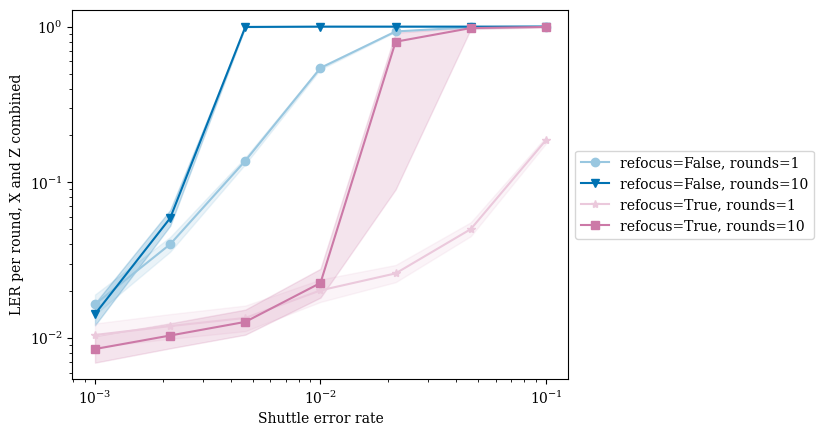

In [37]:
# full decode
fig,ax = plt.subplots()
sinter.plot_error_rate(
    ax=ax,
    stats=combined_stats,
    x_func=lambda s: s.json_metadata['p_sh'],
    group_func=lambda s: f"refocus={s.json_metadata['refoc']}, rounds={s.json_metadata['rounds']}",
    failure_units_per_shot_func=lambda s: s.json_metadata['rounds'],
    plot_args_func=lambda i,key,stats: {'color':plotter.interpolate('C0' if 'False' in key else 'C1', 'w', 0.6*((1-rounds.index(int(key.split('=')[-1])))/1) + 0.0)},
)
plt.loglog()
# leg.remove()
handles, labels = ax.get_legend_handles_labels()
sorted_indices = sorted(range(len(labels)), key=lambda i: labels[i])
ax.legend([handles[i] for i in sorted_indices], [labels[i] for i in sorted_indices], bbox_to_anchor=(1, 0.5), loc='center left')
plt.xlabel('Shuttle error rate')
plt.ylabel('LER per round, X and Z combined')
plt.show()

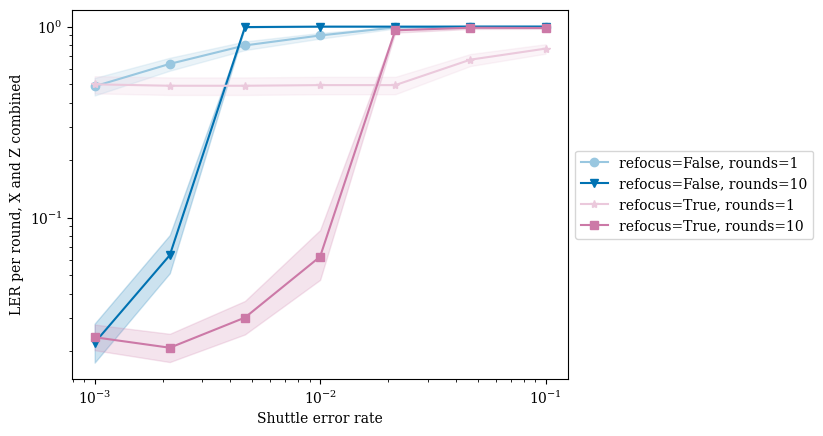

In [43]:
# (5,1) window
fig,ax = plt.subplots()
sinter.plot_error_rate(
    ax=ax,
    stats=combined_stats,
    x_func=lambda s: s.json_metadata['p_sh'],
    group_func=lambda s: f"refocus={s.json_metadata['refoc']}, rounds={s.json_metadata['rounds']}",
    failure_units_per_shot_func=lambda s: s.json_metadata['rounds'],
    plot_args_func=lambda i,key,stats: {'color':plotter.interpolate('C0' if 'False' in key else 'C1', 'w', 0.6*((1-rounds.index(int(key.split('=')[-1])))/1) + 0.0)},
)
plt.loglog()
# leg.remove()
handles, labels = ax.get_legend_handles_labels()
sorted_indices = sorted(range(len(labels)), key=lambda i: labels[i])
ax.legend([handles[i] for i in sorted_indices], [labels[i] for i in sorted_indices], bbox_to_anchor=(1, 0.5), loc='center left')
plt.xlabel('Shuttle error rate')
plt.ylabel('LER per round, X and Z combined')
plt.show()